In [1]:
import pandas as pd, numpy as np
import os
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mtcnn import MTCNN
from typing import List
from tqdm import tqdm

In [2]:
SOURCE_DATA_DIR = "..\\data"

In [3]:
def get_invalid_video_paths(root_dir, expected_frames=75):
    invalid_files = []

    for subdir, _, files in os.walk(root_dir):
        for file in files:
            if file.endswith('.mpg'):
                video_path = os.path.join(subdir, file)
                cap = cv2.VideoCapture(video_path)

                if not cap.isOpened():
                    print(f"Could not open {video_path}")
                    continue

                frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                cap.release()

                if frame_count != expected_frames:
                    invalid_files.append(video_path)
    
    return invalid_files      

In [4]:
import cv2
import os

In [5]:
cap = cv2.VideoCapture("..\\data\\s1_processed\\bbaf2n.mpg")
expected_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
actual_frames = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    actual_frames += 1
    # process frame

cap.release()
print(f"Expected: {expected_frames}, Actual read: {actual_frames}")


Expected: 75, Actual read: 75


In [6]:
import cv2
import tensorflow as tf
import numpy as np
from mtcnn import MTCNN
from typing import List

In [7]:
detector = MTCNN()

In [8]:
cap = cv2.VideoCapture("..\\data\\s1_processed\\bbaf2n.mpg")

In [9]:
ret, frame = cap.read()

In [10]:
results = detector.detect_faces(frame)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step


In [11]:
results

[{'box': [100, 113, 100, 131],
  'confidence': np.float64(0.9999042749404907),
  'keypoints': {'left_eye': (133, 163),
   'right_eye': (180, 161),
   'nose': (160, 192),
   'mouth_left': (141, 218),
   'mouth_right': (178, 217)}}]

In [12]:
left = results[0]['keypoints']['mouth_left']
right = results[0]['keypoints']['mouth_right']
top = results[0]['keypoints']['nose']

In [116]:
frame_shape = frame.shape
margin = 20
x1 = max(left[0] - margin, 0)
y1 = max(top[1]+10, 0)
x2 = min(right[0] + margin, frame_shape[1])
y2 = min(right[1] + margin*2 , frame_shape[0])


In [117]:
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

In [118]:
gray.shape

(288, 360)

In [119]:
gray = gray[y1:y2, x1:x2]

In [120]:
gray.shape

(55, 77)

In [121]:
gray =  np.expand_dims(gray, axis=-1) 
gray.shape

(55, 77, 1)

In [127]:

# Convert to grayscale
gray_resized = tf.image.resize(gray, (50,150))


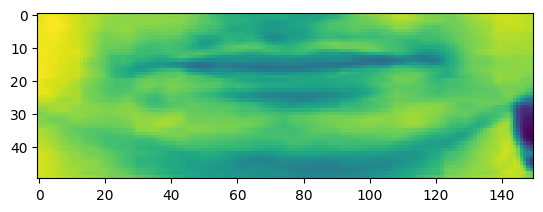

In [129]:
plt.imshow(gray_resized, cmap='viridis')


In [130]:
gray_resized

<tf.Tensor: shape=(50, 150, 1), dtype=float32, numpy=
array([[[178.     ],
        [178.81   ],
        [180.35   ],
        ...,
        [169.35   ],
        [167.81001],
        [167.     ]],

       [[178.     ],
        [178.8505 ],
        [180.4675 ],
        ...,
        [169.2325 ],
        [167.76952],
        [167.     ]],

       [[178.25   ],
        [179.2625 ],
        [181.1875 ],
        ...,
        [168.56667],
        [167.54001],
        [167.     ]],

       ...,

       [[174.     ],
        [173.46   ],
        [172.43333],
        ...,
        [153.78333],
        [130.1702 ],
        [117.75   ]],

       [[174.     ],
        [173.46   ],
        [172.43333],
        ...,
        [162.52002],
        [152.97212],
        [147.95006]],

       [[173.05   ],
        [172.7665 ],
        [172.2275 ],
        ...,
        [161.85   ],
        [154.15005],
        [150.1    ]]], dtype=float32)>

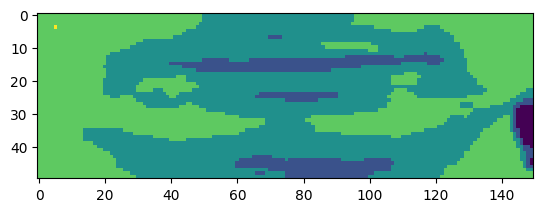

In [131]:
def posterize_image(frame, levels=4):
    frame = frame.numpy()
    frame_normalized = (frame - frame.min()) / (frame.max() - frame.min())  # scale to 0-1
    frame_quantized = (frame_normalized * levels).astype(np.uint8)  # quantize
    return frame_quantized

posterized = posterize_image(gray_resized, levels=4)

plt.imshow(posterized, cmap='viridis')  # or try cmap='plasma' or 'inferno'
plt.show()


In [132]:
import cv2
import tensorflow as tf
import numpy as np
from mtcnn import MTCNN
from typing import List

detector = MTCNN()

def extract_mouth(points, frame_shape, margin = 10):

    left = points[0]['keypoints']['mouth_left']
    right = points[0]['keypoints']['mouth_right']
    top = points[0]['keypoints']['nose']
    x1 = max(left[0] - margin, 0)
    y1 = max(top[1]+10, 0)
    x2 = min(right[0] + margin, frame_shape[1])
    y2 = min(right[1] + margin*2 , frame_shape[0])

    return y1, y2, x1, x2

In [133]:
def load_video(path: str, resize) -> List[float]: 

    frames = []
    cap = cv2.VideoCapture(path)

    ret, frame = cap.read()

    results = detector.detect_faces(frame)

    y1, y2, x1, x2 = extract_mouth(results, frame.shape)
    cap.release()
    cap = cv2.VideoCapture(path)

    for _ in range(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))):

        ret, frame = cap.read()

        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = gray[y1:y2, x1:x2]
        gray =  np.expand_dims(gray, axis=-1) 
        gray_resized = tf.image.resize(gray, resize)
        frames.append(gray_resized)
    cap.release()

    # Convert to tensor and normalize
    frames = tf.stack(frames)
    mean = tf.math.reduce_mean(frames)
    std = tf.math.reduce_std(tf.cast(frames, tf.float32))

    return tf.cast((frames - mean), tf.float32) / std
    
    

In [134]:
def process_and_save_all_videos(input_root, output_root, invalid_videos, resize):
    os.makedirs(output_root, exist_ok=True)

    for speaker in sorted(os.listdir(input_root)):
        speaker_path = os.path.join(input_root, speaker)
        if not os.path.isdir(speaker_path):
            continue

        output_speaker_dir = os.path.join(output_root, speaker)
        os.makedirs(output_speaker_dir, exist_ok=True)

        for video_file in tqdm(os.listdir(speaker_path), desc=f"Processing {speaker}"):
            if not video_file.endswith(".mpg"):
                continue

            video_path = os.path.join(speaker_path, video_file)
            if video_path not in invalid_videos:
                try:
                    frames_tensor = load_video(video_path, resize=resize)  # (T, H, W, 1)
                    frames_np = frames_tensor.numpy()
                    video_id = os.path.splitext(video_file)[0]
                    npy_path = os.path.join(output_speaker_dir, f"{video_id}.npy")
                    np.save(npy_path, frames_np)
                except Exception as e:
                    print(f"Failed on {video_path}: {e}")


In [36]:
a = np.load("..\\processed_data\\s1_processed\\bbaf2n.npy" )

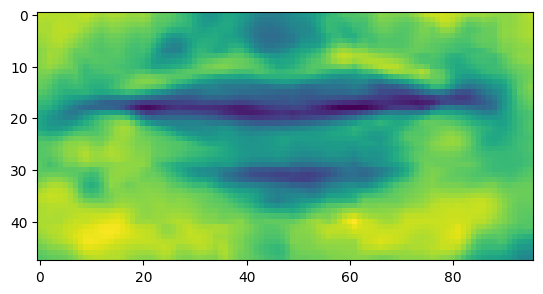

In [39]:
plt.imshow(a[74])

In [135]:
SOURCE_DATA_DIR = "..\\data"
output_dir = "..\\processed_data1" 

# invalid speakers with no 75 frames
invalid_video_paths = get_invalid_video_paths(SOURCE_DATA_DIR, expected_frames=75)
# List of speakers to process

process_and_save_all_videos(SOURCE_DATA_DIR, output_dir, invalid_video_paths, resize=(50, 150))

Processing s1_processed:   0%|                                                                | 0/1001 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step


Processing s1_processed:   0%|                                                        | 2/1001 [00:03<27:51,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step


Processing s1_processed:   0%|▏                                                       | 3/1001 [00:06<39:48,  2.39s/it]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


Processing s1_processed:   1%|▊                                                      | 14/1001 [00:31<37:16,  2.27s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


Processing s1_processed:   1%|▊                                                      | 14/1001 [00:32<37:50,  2.30s/it]
C:\Users\manik\Desktop\Capstone_Final_Project\lipreading_env\lib\site-packages\mtcnn\mtcnn.py:206: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if method is 'Min':
C:\Users\manik\Desktop\Capstone_Final_Project\lipreading_env\lib\site-packages\mtcnn\mtcnn.py:206: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if method is 'Min':
C:\Users\manik\Desktop\Capstone_Final_Project\lipreading_env\lib\site-packages\mtcnn\mtcnn.py:206: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if method is 'Min':
C:\Users\manik\Desktop\Capstone_Final_Project\lipreading_env\lib\site-packages\mtcnn\mtcnn.py:206: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if method is 'Min':


KeyboardInterrupt: 

In [138]:
path = "..\\processed_data1\\s1_processed\\bbaf2n.npy"

In [139]:
a = np.load(path)

In [140]:
a.shape

(75, 50, 150, 1)

In [87]:
!pip install imageio

You should consider upgrading via the 'c:\users\manik\desktop\capstone_final_project\lipreading_env\scripts\python.exe -m pip install --upgrade pip' command.


In [141]:
import imageio

In [142]:
a = [(frame * 255).astype(np.uint8) for frame in a]

In [146]:
a = a.reshape(75,50,150)

In [144]:
a = np.array(a)

In [147]:
a.shape

(75, 50, 150)

In [155]:
imageio.mimsave("lip_sequence.gif", a, fps=10)

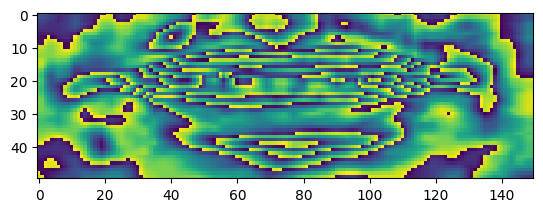

In [154]:
plt.imshow(a[20])